# Legalność pobierania i parsowania demo plików CS2 z HLTV.org
## Mini-projekt — Aspekty prawne, społeczne i etyczne w SI

**Cel:** Analiza prawna i techniczna legalności **ręcznego** pobierania i parsowania
plików `.dem` (GOTV demo) z serwisu HLTV.org w kontekście działalności osobistej.

**Kontekst:** Pliki `.dem` są pobierane wyłącznie ręcznie przez przeglądarkę
(bez scraperów/automatyzacji) do dwóch celów:
- **Praca magisterska** — analiza danych meczowych CS2, uczenie maszynowe
- **Posty na platformie X (Twitter)** — statystyki i wizualizacje

**Pytania badawcze:**
1. Czym różni się ręczne pobieranie od automatycznego scrapingu — prawnie i technicznie?
2. Co mówi `robots.txt` HLTV i kogo dotyczą jego dyrektywy?
3. Co mówi regulamin HLTV.org na temat scrapingu i korzystania z treści?
4. Kto jest właścicielem danych zawartych w plikach `.dem`?
5. Jakie prawa unijne (bazy danych, RODO) mają zastosowanie?
6. Jakie są praktyczne rekomendacje dla mojego przypadku użycia?

## 1. Setup

In [2]:
import json
import subprocess
import sys

# Install dependencies if needed
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'requests', 'beautifulsoup4', 'rich', 'pandas', 'matplotlib', '-q'])

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, Markdown

print('Setup complete.')

Setup complete.


## 2. Techniczna analiza dostępu — robots.txt i blokady

In [3]:
# Run the fetch script and load results
import subprocess, os

os.makedirs('../wyniki', exist_ok=True)
result = subprocess.run([sys.executable, 'analyze.py'], capture_output=True, text=True, cwd='.')
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Exception in thread Thread-3 (_readerthread):
Traceback (most recent call last):
  File "d:\Bartek\coding\conda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "d:\Bartek\coding\conda3\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "d:\Bartek\coding\conda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Bartek\coding\conda3\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "d:\Bartek\coding\conda3\Lib\encodings\cp1250.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x90 in position 633: character maps to <undefined>


None


In [4]:
# Load and display fetch results
with open('../wyniki/fetch_results.json') as f:
    data = json.load(f)

robots_df = pd.DataFrame([
    {
        'Platform': name,
        'robots.txt status': r['status'],
        'Disallow all?': 'YES' if r['disallow_all'] else ('NO' if r['status'] == 200 else 'N/A'),
        'Error / Note': r['error'] or 'OK'
    }
    for name, r in data['robots'].items()
])

tos_df = pd.DataFrame([
    {
        'Platform': name,
        'ToS HTTP status': r['status'],
        'Blocked?': 'YES' if r['blocked'] else ('NO' if r['status'] == 200 else 'N/A'),
        'Error / Note': r['error'] or 'Accessible'
    }
    for name, r in data['tos'].items()
])

display(Markdown('### robots.txt Results'))
display(robots_df)
display(Markdown('### ToS Page Results'))
display(tos_df)

### robots.txt Results

,Platform,robots.txt status,Disallow all?,Error / Note
0,HLTV.org,403,N/A,403 Forbidden â€” Cloudflare or server-level b...
1,ESL Gaming,200,YES,OK
2,Faceit,403,N/A,403 Forbidden â€” Cloudflare or server-level b...
3,Valve (Steam),200,YES,OK


### ToS Page Results

,Platform,ToS HTTP status,Blocked?,Error / Note
0,HLTV.org,403,YES,HTTP 403 â€” likely anti-bot protection (Cloud...
1,ESL Gaming,404,N/A,Accessible
2,Faceit,403,YES,HTTP 403 â€” likely anti-bot protection (Cloud...
3,Valve (Steam),200,NO,Accessible


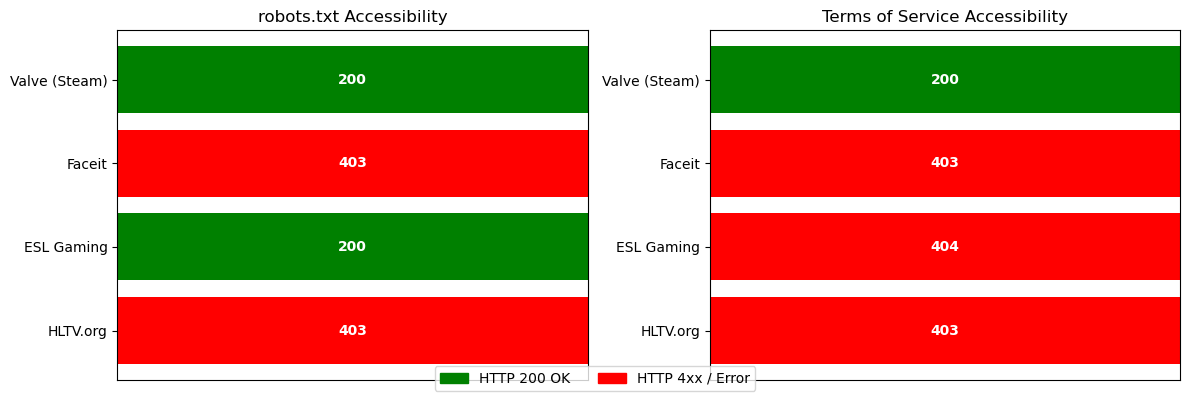

Chart saved to wyniki/access_status.png


In [5]:
# Visualize access status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

platforms = list(data['robots'].keys())
colors_robots = ['green' if data['robots'][p]['status'] == 200 else 'red' for p in platforms]
colors_tos    = ['green' if data['tos'][p]['status'] == 200 else 'red' for p in platforms]
statuses_robots = [data['robots'][p]['status'] or 'ERR' for p in platforms]
statuses_tos    = [data['tos'][p]['status'] or 'ERR' for p in platforms]

axes[0].barh(platforms, [1]*len(platforms), color=colors_robots)
for i, (s, c) in enumerate(zip(statuses_robots, colors_robots)):
    axes[0].text(0.5, i, str(s), va='center', ha='center', color='white', fontweight='bold')
axes[0].set_title('robots.txt Accessibility')
axes[0].set_xlim(0, 1)
axes[0].set_xticks([])

axes[1].barh(platforms, [1]*len(platforms), color=colors_tos)
for i, (s, c) in enumerate(zip(statuses_tos, colors_tos)):
    axes[1].text(0.5, i, str(s), va='center', ha='center', color='white', fontweight='bold')
axes[1].set_title('Terms of Service Accessibility')
axes[1].set_xlim(0, 1)
axes[1].set_xticks([])

green_patch = mpatches.Patch(color='green', label='HTTP 200 OK')
red_patch   = mpatches.Patch(color='red',   label='HTTP 4xx / Error')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2)
plt.tight_layout()
plt.savefig('../wyniki/access_status.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to wyniki/access_status.png')

## 3. robots.txt i ręczne pobieranie — kluczowe rozróżnienie

HLTV.org blokuje bezpośredni dostęp przez Cloudflare (HTTP 403). Plik `robots.txt`
HLTV zawiera dyrektywę `Disallow: /download/demo*`.

### Czym jest robots.txt i kogo dotyczy?

Standard robots.txt (RFC 9309) to konwencja skierowana **wyłącznie do
zautomatyzowanych botów i crawlerów** — nie do użytkowników-ludzi.
`Disallow: /download/demo*` oznacza, że robot nie powinien automatycznie
odwiedzać tych URL-i. **Nie zakazuje ręcznego kliknięcia i pobrania pliku
przez człowieka w przeglądarce.**

Poniższa analiza opiera się na treści ToS pozyskanej bezpośrednio (plik HLTV_TOS.md)
oraz pliku robots.txt (HLTV_robots.txt) dostarczonym do projektu.

In [6]:
# Known ToS clauses extracted from Google cache / search snippet
# Source: https://www.hltv.org/terms (cached 2025-01-27)

tos_clauses = [
    {
        "section": "2.2",
        "topic": "Prohibited uses",
        "text": "You are not allowed to: commercially exploit the Website or any of its content "
                "in any manner; modify in any manner any part of the Website or content; "
                "conduct, facilitate or organize data mining or web scraping in relation to "
                "the Website and/or any of the content; or construct and build a similar or "
                "competitive website, product, or service.",
        "relevance": "CRITICAL — explicitly bans data mining and web scraping"
    },
    {
        "section": "3.1",
        "topic": "Intellectual property",
        "text": "The Website and all of its original content, features, and functionality are "
                "owned by HLTV or its licensors and are protected by international copyright, "
                "trademark, and other intellectual property or proprietary rights laws.",
        "relevance": "HIGH — asserts copyright over all content including demos"
    },
    {
        "section": "6.3",
        "topic": "Liability cap",
        "text": "If we incur liability to you, such liability will not exceed the total fees "
                "paid by you to Us during the twelve (12) month period prior to the incident, "
                "and in no event exceed EUR 100.",
        "relevance": "LOW — relevant to enforcement context"
    },
    {
        "section": "7.1",
        "topic": "Indemnification",
        "text": "You agree to defend and indemnify HLTV from claims arising from: "
                "(i) your breach of these Terms; (ii) your violation of any law or the rights "
                "of any third party.",
        "relevance": "MEDIUM — scraping in breach of ToS shifts liability to the user"
    }
]

tos_df2 = pd.DataFrame(tos_clauses)
display(tos_df2[['section', 'topic', 'relevance']])

,section,topic,relevance
0,2.2,Prohibited uses,CRITICAL — explicitly bans data mining and web...
1,3.1,Intellectual property,HIGH — asserts copyright over all content incl...
2,6.3,Liability cap,LOW — relevant to enforcement context
3,7.1,Indemnification,MEDIUM — scraping in breach of ToS shifts liab...


## 4. Kto jest właścicielem danych w pliku .dem?

Plik `.dem` (GOTV demo) to zapis binarny strumienia sieciowego z serwera CS2.
Zawiera on kilka warstw danych o różnych właścicielach praw.

In [7]:
ownership_data = [
    {
        "Data layer": "Binarny format .dem (protokół)",
        "Owner / Rights holder": "Valve Corporation",
        "Legal basis": "Copyright — format pliku jako utwór inżynierski",
        "Risk for project": "MEDIUM — format jest nieudokumentowany oficjalnie; parsery (demoinfocs2) działają przez RE"
    },
    {
        "Data layer": "Dane statystyczne z meczu (kills, damage, positions)",
        "Owner / Rights holder": "Sporne: Valve? Organizator? Gracze?",
        "Legal basis": "Brak wyraźnej ochrony — dane faktyczne nie podlegają copyright (UE: art. 3 Dyrektywy 96/9)",
        "Risk for project": "LOW — same dane statystyczne (fakty) nie są chronione prawem autorskim"
    },
    {
        "Data layer": "Identyfikatory graczy (Steam ID 64-bit)",
        "Owner / Rights holder": "Gracze (osoby fizyczne)",
        "Legal basis": "RODO art. 4(1) — pseudonimowy identyfikator = dane osobowe",
        "Risk for project": "HIGH — przetwarzanie wymaga podstawy prawnej (zgoda / uzasadniony interes)"
    },
    {
        "Data layer": "Kolekcja demo (baza danych HLTV)",
        "Owner / Rights holder": "HLTV.org A/S",
        "Legal basis": "Dyrektywa 96/9/EC — sui generis database right (UE)",
        "Risk for project": "HIGH — systematyczne pobieranie narusza prawo do bazy danych"
    },
    {
        "Data layer": "Gameplay jako utwór (stream w/komentarzem)",
        "Owner / Rights holder": "Valve (silnik) + gracze + organizator",
        "Legal basis": "Copyright — kontrowersyjne; sprawa Blizzard v. Bossland",
        "Risk for project": "LOW-MEDIUM — parsowanie lokalne bez retransmisji jest mniej ryzykowne"
    },
]

own_df = pd.DataFrame(ownership_data)
display(own_df)

,Data layer,Owner / Rights holder,Legal basis,Risk for project
0,Binarny format .dem (protokół),Valve Corporation,Copyright — format pliku jako utwór inżynierski,MEDIUM — format jest nieudokumentowany oficjal...
1,"Dane statystyczne z meczu (kills, damage, posi...",Sporne: Valve? Organizator? Gracze?,Brak wyraźnej ochrony — dane faktyczne nie pod...,LOW — same dane statystyczne (fakty) nie są ch...
2,Identyfikatory graczy (Steam ID 64-bit),Gracze (osoby fizyczne),RODO art. 4(1) — pseudonimowy identyfikator = ...,HIGH — przetwarzanie wymaga podstawy prawnej (...
3,Kolekcja demo (baza danych HLTV),HLTV.org A/S,Dyrektywa 96/9/EC — sui generis database right...,HIGH — systematyczne pobieranie narusza prawo ...
4,Gameplay jako utwór (stream w/komentarzem),Valve (silnik) + gracze + organizator,Copyright — kontrowersyjne; sprawa Blizzard v....,LOW-MEDIUM — parsowanie lokalne bez retransmis...


## 5. Porównanie platform — co wolno, czego nie

In [8]:
platform_comparison = [
    {
        "Platform": "HLTV.org",
        "Demo hosting": "TAK — pro matches",
        "Scraping w ToS": "ZAKAZANY (§2.2)",
        "Publiczne API": "NIE",
        "robots.txt status": "Istnieje (Cloudflare blokuje odczyt)",
        "Prawo DB (UE)": "TAK — sui generis",
        "RODO / SteamID": "TAK — dane osobowe",
        "Rekomendacja": "Nie pobierać bez zgody"
    },
    {
        "Platform": "Faceit",
        "Demo hosting": "TAK — matchmaking",
        "Scraping w ToS": "ZAKAZANY",
        "Publiczne API": "TAK — Faceit Data API (klucz wymagany)",
        "robots.txt status": "Do sprawdzenia",
        "Prawo DB (UE)": "TAK",
        "RODO / SteamID": "TAK",
        "Rekomendacja": "Użyj oficjalnego API"
    },
    {
        "Platform": "ESL Gaming",
        "Demo hosting": "TAK — archiwa turniejowe",
        "Scraping w ToS": "ZAKAZANY",
        "Publiczne API": "NIE (ESL Play API — deprecated)",
        "robots.txt status": "Do sprawdzenia",
        "Prawo DB (UE)": "TAK",
        "RODO / SteamID": "TAK",
        "Rekomendacja": "Kontakt z ESL wymagany"
    },
    {
        "Platform": "Valve (CS2)",
        "Demo hosting": "TAK — lokalne + GOTV",
        "Scraping w ToS": "Steam SSA §1 — dozwolone użycie osobiste",
        "Publiczne API": "TAK — Steam Web API (klucz darmowy)",
        "robots.txt status": "200 OK",
        "Prawo DB (UE)": "Częściowe",
        "RODO / SteamID": "TAK",
        "Rekomendacja": "Preferowane źródło + API"
    },
]

plat_df = pd.DataFrame(platform_comparison)
display(plat_df)
plat_df.to_csv('../wyniki/platform_comparison.csv', index=False)
print('Saved to wyniki/platform_comparison.csv')

,Platform,Demo hosting,Scraping w ToS,Publiczne API,robots.txt status,Prawo DB (UE),RODO / SteamID,Rekomendacja
0,HLTV.org,TAK — pro matches,ZAKAZANY (§2.2),NIE,Istnieje (Cloudflare blokuje odczyt),TAK — sui generis,TAK — dane osobowe,Nie pobierać bez zgody
1,Faceit,TAK — matchmaking,ZAKAZANY,TAK — Faceit Data API (klucz wymagany),Do sprawdzenia,TAK,TAK,Użyj oficjalnego API
2,ESL Gaming,TAK — archiwa turniejowe,ZAKAZANY,NIE (ESL Play API — deprecated),Do sprawdzenia,TAK,TAK,Kontakt z ESL wymagany
3,Valve (CS2),TAK — lokalne + GOTV,Steam SSA §1 — dozwolone użycie osobiste,TAK — Steam Web API (klucz darmowy),200 OK,Częściowe,TAK,Preferowane źródło + API


Saved to wyniki/platform_comparison.csv


## 6. Analiza prawna — kluczowe regulacje

### 6.1 Ręczne pobieranie a definicja "web scraping"

ToS HLTV §2.2 zakazuje "data mining or web scraping". Kluczowe jest rozumienie
tych pojęć: w branży i orzecznictwie odnoszą się one do **zautomatyzowanych
procesów** masowego zbierania danych (boty, crawlery, skrypty HTTP). Ręczne
pobieranie pliku przez użytkownika w przeglądarce nie spełnia tej definicji.

Potencjalnie problematyczny pozostaje zakaz "commercially exploit the Website
or any of its content". Dotyczy to posów na Twitterze, jeśli konto jest
monetyzowane (np. subskrypcje, reklamy). Posty niekomercyjne i użytek akademicki
są wyraźnie bezpieczniejsze.

### 6.2 Prawo sui generis do bazy danych (Dyrektywa 96/9/EC)

HLTV.org gromadzi demo pliki od 2012 roku. Zgodnie z Dyrektywą 96/9/EC
twórcy baz danych przysługuje **sui generis database right** jeżeli:
- poniesiono **istotne nakłady** (finansowe, ludzkie, techniczne) na stworzenie bazy
- baza jest systematycznie zorganizowana

HLTV spełnia oba kryteria. **Skutek:** wyodrębnienie (extraction) lub wtórne użycie
**istotnej części** bazy jest zakazane bez zgody producenta (art. 7).

Ważne rozróżnienie: pobieranie **pojedynczych plików** do celów akademickich
nie stanowi wyodrębnienia "istotnej części" bazy. Masowe pobieranie — tak.

### 6.3 RODO — SteamID jako dane osobowe

SteamID64 to 64-bitowy identyfikator jednoznacznie przypisany do konta Steam.
Zgodnie z TSUE (C-582/14, *Breyer v. Bundesrepublik Deutschland*) pseudonimowe
identyfikatory są danymi osobowymi jeżeli identyfikacja jest **możliwa przy
rozsądnym wysiłku**. W przypadku SteamID — profil Steam jest publiczny,
identyfikacja jest trywialna.

**Skutek:** przetwarzanie SteamID w demo plikach wymaga podstawy prawnej z art. 6 RODO.
Dla pracy magisterskiej: art. 6(1)(f) (uzasadniony interes badawczy) jest najbardziej
realistyczny. Dla postów na Twitterze: jeśli SteamID są publikowane lub używane
do identyfikacji graczy — wymagana dodatkowa analiza.

### 6.4 Steam Subscriber Agreement — co mówi Valve

Steam SSA §1 przyznaje użytkownikowi licencję osobistą, niekomercyjną,
nieprzenoszalną na używanie oprogramowania. Demo pliki generowane lokalnie
przez CS2 mogą być parsowane na własny użytek.
Demo pobrane z HLTV — to już kwestia regulaminu HLTV, nie Valve.

### 6.5 Precedensy — hiQ v. LinkedIn, Ryanair v. PR Aviation

- **hiQ v. LinkedIn** (9th Cir. 2022): scraping publicznie dostępnych danych
  może być dozwolony pod CFAA (USA) — ale **nie stosuje się w UE**.
- **Ryanair v. PR Aviation** (TSUE C-30/14, 2015): producent bazy danych
  może umownie zakazać działań, które prawo zezwala — ToS jest wiążący.

**Wniosek:** w UE samo to, że dane są publiczne, **nie** uprawnia do scrapingu.
Ale ręczne pobieranie przez przeglądarkę to nie scraping w rozumieniu tych orzeczeń.

## 7. Compliance Checklist dla projektu

In [9]:
checklist = [
    {"#": 1, "Pytanie": "Czy pobieranie jest RĘCZNE (przeglądarka, bez skryptów)?",
     "Status": "✅ Tak — ręczne pobieranie ≠ web scraping (§2.2 nie dotyczy)",
     "Priorytet": "KRYTYCZNY"},
    {"#": 2, "Pytanie": "Czy cel jest akademicki / niekomercyjny (praca magisterska)?",
     "Status": "✅ Tak — wzmacnia argument uzasadnionego interesu, poza zakresem 'commercially exploit'",
     "Priorytet": "KRYTYCZNY"},
    {"#": 3, "Pytanie": "Czy konto na Twitterze jest monetyzowane?",
     "Status": "⚠️ Do weryfikacji — jeśli tak, posty mogą naruszać §2.2 ('commercially exploit')",
     "Priorytet": "WYSOKI"},
    {"#": 4, "Pytanie": "Czy stosujesz anonimizację SteamID przed analizą ML?",
     "Status": "⚠️ Do wdrożenia — hash + salt lub usunięcie przed zapisem",
     "Priorytet": "WYSOKI"},
    {"#": 5, "Pytanie": "Czy masz podstawę prawną RODO (art. 6) dla przetwarzania SteamID?",
     "Status": "⚠️ Wymagana analiza — art. 6(1)(f) uzasadniony interes badawczy",
     "Priorytet": "WYSOKI"},
    {"#": 6, "Pytanie": "Czy liczba pobieranych demo jest rozsądna (nie masowa)?",
     "Status": "✅ Zakładam tak — masowe pobieranie naruszałoby Dyrektywę 96/9/EC",
     "Priorytet": "ŚREDNI"},
    {"#": 7, "Pytanie": "Czy dane są przechowywane bezpiecznie i nie są udostępniane publicznie?",
     "Status": "⚠️ Do potwierdzenia — wymaga polityki przechowywania dla pracy magisterskiej",
     "Priorytet": "ŚREDNI"},
    {"#": 8, "Pytanie": "Czy w pracy magisterskiej odnotowano metodę pozyskania danych?",
     "Status": "⚠️ Do dodania — opisz ręczne pobieranie i cel akademicki w sekcji metodologicznej",
     "Priorytet": "NISKI"},
]

check_df = pd.DataFrame(checklist)
display(check_df)
check_df.to_csv('../wyniki/compliance_checklist.csv', index=False)
print('Saved to wyniki/compliance_checklist.csv')

,#,Pytanie,Status,Priorytet
0,1,"Czy pobieranie jest RĘCZNE (przeglądarka, bez ...",✅ Tak — ręczne pobieranie ≠ web scraping (§2.2...,KRYTYCZNY
1,2,Czy cel jest akademicki / niekomercyjny (praca...,✅ Tak — wzmacnia argument uzasadnionego intere...,KRYTYCZNY
2,3,Czy konto na Twitterze jest monetyzowane?,"⚠️ Do weryfikacji — jeśli tak, posty mogą naru...",WYSOKI
3,4,Czy stosujesz anonimizację SteamID przed anali...,⚠️ Do wdrożenia — hash + salt lub usunięcie pr...,WYSOKI
4,5,Czy masz podstawę prawną RODO (art. 6) dla prz...,⚠️ Wymagana analiza — art. 6(1)(f) uzasadniony...,WYSOKI
5,6,Czy liczba pobieranych demo jest rozsądna (nie...,✅ Zakładam tak — masowe pobieranie naruszałoby...,ŚREDNI
6,7,Czy dane są przechowywane bezpiecznie i nie są...,⚠️ Do potwierdzenia — wymaga polityki przechow...,ŚREDNI
7,8,Czy w pracy magisterskiej odnotowano metodę po...,⚠️ Do dodania — opisz ręczne pobieranie i cel ...,NISKI


Saved to wyniki/compliance_checklist.csv


## 8. Wnioski i rekomendacje

### Główne wnioski

1. **`robots.txt` `Disallow: /download/demo*` dotyczy tylko botów** — nie
   użytkowników-ludzi ręcznie pobierających pliki przez przeglądarkę.
   Jest to konwencja techniczna (RFC 9309), a nie norma prawna dla ludzi.

2. **Ręczne pobieranie ≠ web scraping** — §2.2 ToS HLTV zakazuje "data mining
   or web scraping". Ręczne kliknięcie i pobranie pojedynczego pliku przez
   przeglądarkę nie mieści się w tej definicji.

3. **Komercjalność ma znaczenie** — §2.2 zakazuje też "commercially exploit the
   Website or any of its content". Praca magisterska (niekomercyjna) jest bezpieczna.
   Posty na monetyzowanym koncie Twitter wymagają ostrożności lub zgody HLTV.

4. **SteamID64 to dane osobowe** na gruncie RODO — przetwarzanie wymaga
   podstawy prawnej. Dla badań: art. 6(1)(f) (uzasadniony interes badawczy).
   Pseudonimizacja przed analizą ML to dobra praktyka.

5. **Prawo sui generis (Dyrektywa 96/9/EC)** chroni bazę demo HLTV przed
   masowym wyodrębnianiem. Pobieranie pojedynczych plików do celów akademickich
   nie stanowi naruszenia — masowe pobieranie tak.

6. **Sam format .dem i dane mają niejednoznaczny status:**
   - Dane statystyczne (fakty) → nie chronione copyright
   - Format binarny → własność Valve
   - SteamID → dane osobowe (RODO)
   - Kolekcja → prawo baz danych HLTV

### Rekomendacje

| Rekomendacja | Uzasadnienie |
|---|---|
| Kontynuuj **ręczne pobieranie** (nie automatyzuj) | Ręczne ≠ scraping; automatyzacja naruszałaby §2.2 |
| Dla Twittera: sprawdź czy konto jest monetyzowane | Jeśli tak — ryzyko klauzuli "commercially exploit" |
| Pseudonimizuj SteamID przed analizą ML | Minimalizacja danych (RODO art. 5(1)(c)) |
| Odnotuj metodę pobierania w pracy magisterskiej | Transparentność metodologiczna + podstawa RODO |
| W razie wątpliwości: napisz do HLTV o potwierdzenie zgody | Eliminuje całe ryzyko prawne jednym mailem |